In [10]:
import librosa
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# Enhacement de los audios propios

In [4]:
SAMPLING_RATE = 16_000
CUTOFF_HZ = 4_000

In [6]:
folder = '../audios_propios'

paths = []

for file in os.listdir(folder):
    if 'respiracion_larga' in file:
        paths.append(os.path.join(folder, file))

paths


['../audios_propios\\respiracion_larga.ogg',
 '../audios_propios\\respiracion_larga2.ogg',
 '../audios_propios\\respiracion_larga3.ogg',
 '../audios_propios\\respiracion_larga4.ogg',
 '../audios_propios\\respiracion_larga5.ogg',
 '../audios_propios\\respiracion_larga6.ogg']

La respiración 4 contiene un wheeze

## Pasos obligatorios del pipeline:

In [17]:
def lowpass_filter(y, sr, cutoff_hz=CUTOFF_HZ, order=6):
    nyq = 0.5 * sr
    normal_cutoff = cutoff_hz / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y_filt = filtfilt(b, a, y)
    return y_filt


def filter_and_resample(path, sr_target=SAMPLING_RATE):
    y, sr = librosa.load(path, sr=None)
    y = lowpass_filter(y, sr, cutoff_hz=CUTOFF_HZ)
    if sr != sr_target:
        y = librosa.resample(y, orig_sr=sr, target_sr=sr_target)
    return y, sr_target

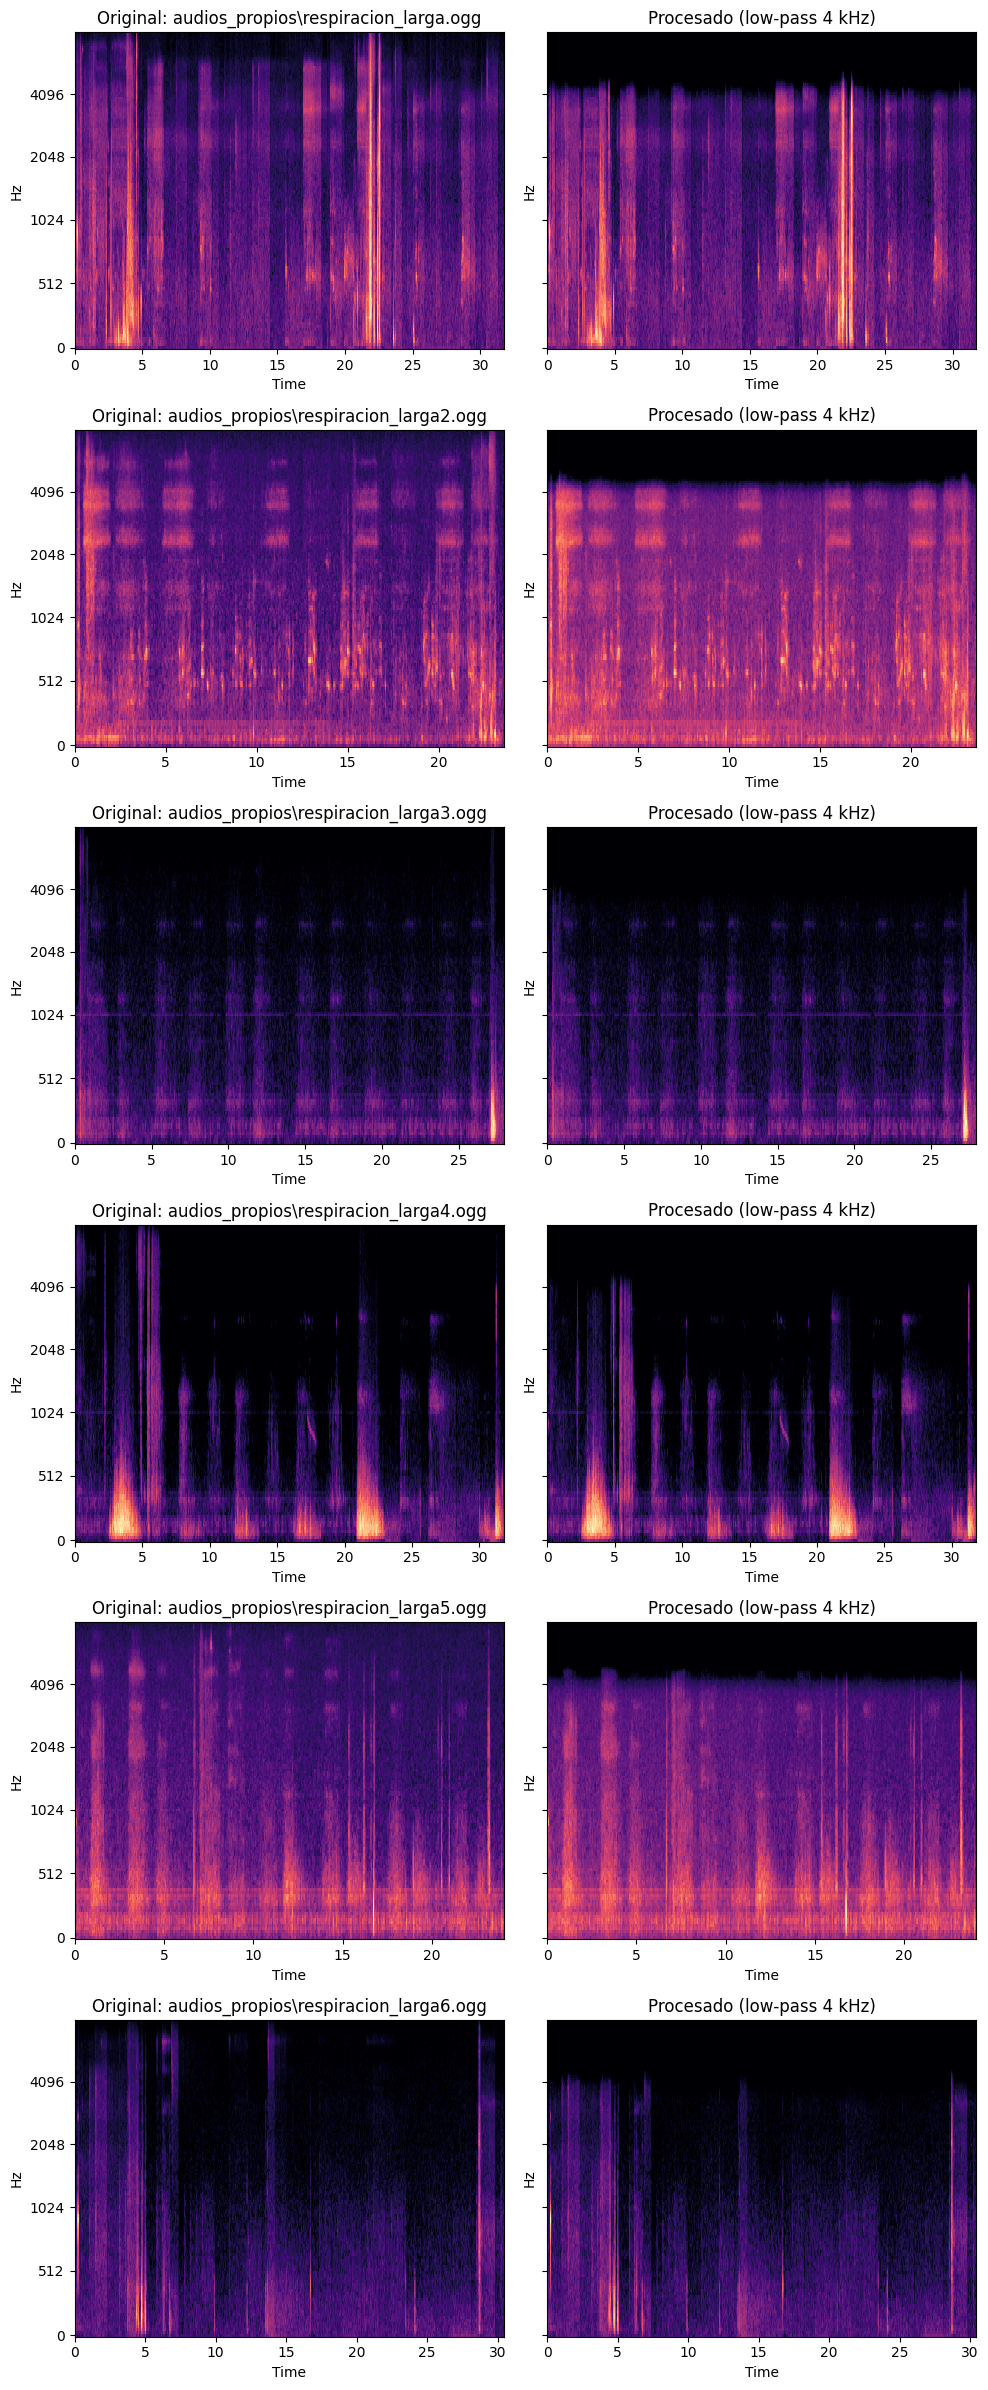

In [23]:
fig, axes = plt.subplots(len(paths), 2, figsize=(10, 4 * len(paths)), sharey=True)

for i, path in enumerate(paths):
    # Cargar original
    y, sr = librosa.load(path, sr=None)
    melspec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    melspec_db = librosa.power_to_db(melspec, ref=np.max)

    # Cargar procesado
    y_proc, sr_proc = filter_and_resample(path)
    melspec_proc = librosa.feature.melspectrogram(y=y_proc, sr=sr_proc, n_mels=128)
    melspec_proc_db = librosa.power_to_db(melspec_proc, ref=np.max)

    # Plot original
    ax_orig = axes[i, 0] if len(paths) > 1 else axes[0]
    img1 = librosa.display.specshow(
        melspec_db, sr=sr, x_axis='time', y_axis='mel', ax=ax_orig
    )
    ax_orig.set_title(f"Original: {path.split('/')[-1]}")
    # fig.colorbar(img1, ax=ax_orig, format="%+2.0f dB")

    # Plot procesado
    ax_proc = axes[i, 1] if len(paths) > 1 else axes[1]
    img2 = librosa.display.specshow(
        melspec_proc_db, sr=sr_proc, x_axis='time', y_axis='mel', ax=ax_proc
    )
    ax_proc.set_title("Procesado (low-pass 4 kHz)")
    # fig.colorbar(img2, ax=ax_proc, format="%+2.0f dB")

plt.tight_layout()
plt.show()


Esa "S" en el audio 4 segundo 17 es un wheeze, vi algo parecido en ICBHI

## Segmentación
Ahora vamos a lo más importante, somos capaces de dividir los audios en ciclos?

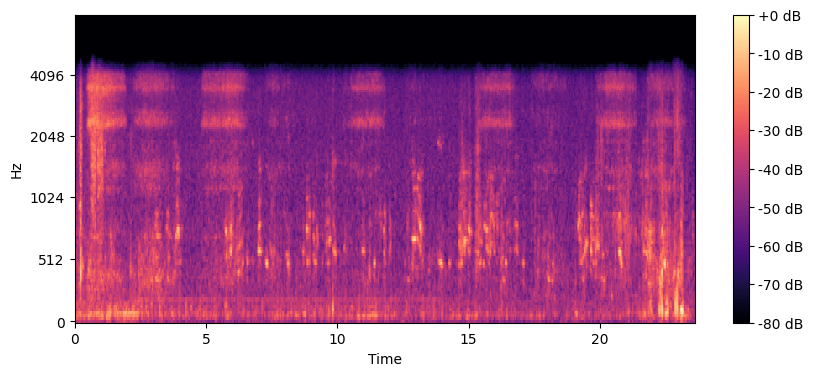

In [38]:
# elijo un audio para segmentar

y, sr = filter_and_resample(paths[1])

def melspectrogram(y, sr):
    melspec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    melspec_db = librosa.power_to_db(melspec, ref=np.max)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(melspec_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format="%+2.0f dB")
    plt.show()

melspectrogram(y, sr)

### Energy Based

1. calculamos la energía local

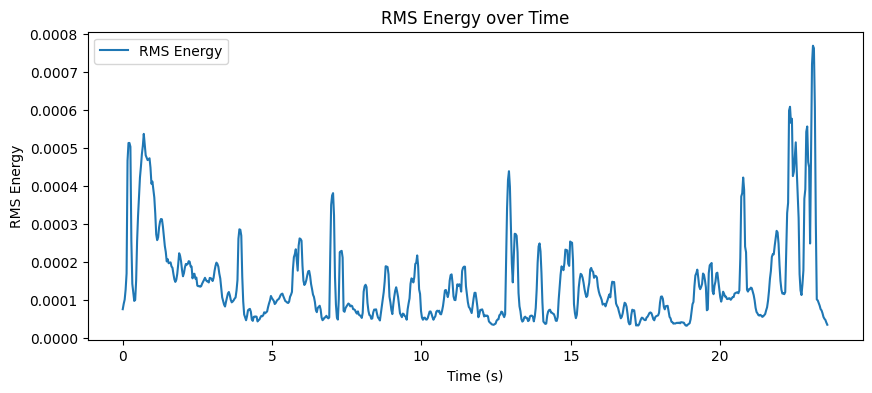

In [39]:
rms = librosa.feature.rms(y=y, frame_length=2048, hop_length=512)[0]
times = librosa.times_like(rms, sr=sr, hop_length=512)

plt.figure(figsize=(10, 4))
plt.plot(times, rms, label='RMS Energy')
plt.xlabel('Time (s)')
plt.ylabel('RMS Energy')
plt.title('RMS Energy over Time')
plt.legend()
plt.show()


11 ciclos detectados
0.03s - 4.06s
4.86s - 6.46s
8.67s - 8.99s
9.57s - 9.98s
10.72s - 11.65s
12.83s - 13.31s
14.59s - 15.14s
15.23s - 16.61s
19.07s - 19.55s
19.62s - 21.22s
21.57s - 23.36s


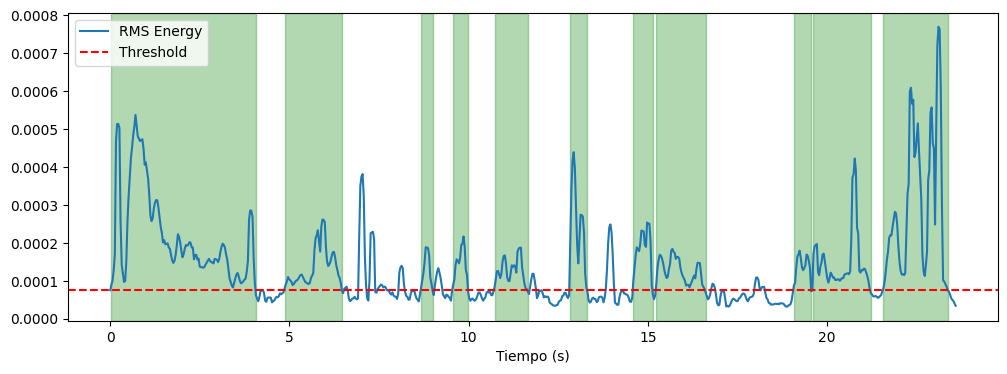

In [44]:
# Umbral dinámico
threshold = 0.1 * np.max(rms)

# Máscara de actividad
active = rms > threshold

# Encontrar transiciones inicio/fin
segments = []
start = None
for i, val in enumerate(active):
    if val and start is None:
        start = times[i]
    elif not val and start is not None:
        end = times[i]
        if end - start > 0.3:  # mínimo 0.3s (para evitar ruido corto)
            segments.append((start, end))
        start = None

print(f"{len(segments)} ciclos detectados")
for s in segments:
    print(f"{s[0]:.2f}s - {s[1]:.2f}s")

# Visualizar
plt.figure(figsize=(12, 4))
plt.plot(times, rms, label='RMS Energy')
plt.axhline(threshold, color='r', linestyle='--', label='Threshold')
for (s, e) in segments:
    plt.axvspan(s, e, color='green', alpha=0.3)
plt.xlabel("Tiempo (s)")
plt.legend()
plt.show()

Prometedor.

Quizás conviene hacer sustraccion espectral para quitar ruido, es sólo para identificar los ciclos. El audio original seguirá sin cambios.